# Homework assignment №3
## Author: Danuta Grabovska

As usual, we start from importing and preprocessing data. For this homework, I chose [Mammography](https://www.openml.org/search?type=data&sort=version&status=any&order=asc&exact_name=mammography&id=310) to perform logistic regression on.

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_openml
data = fetch_openml(name="mammography", version=1, as_frame=True)

In [73]:
from sklearn.model_selection import train_test_split
X = data.data
y = data.target.map({"-1": 0, "1": 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2137, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=2137, stratify=y_train) # 0.25 x 0.8 = 0.2

As we have our train, validation and test split, it's time to fit logistic regression on the train set. Then we can use validation set to plot ROC (Receiver Operating Characteristics) curve, which plots false positive rate against true positive rate at each threshold setting. Based on the curve, we can calculate area under it, that would tell us the probability that a classifier will rank a randomly chosen positive instance higher than a randomly chosen negative one.

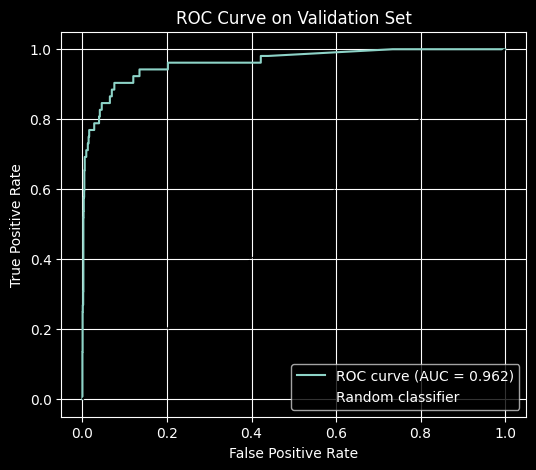

In [74]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_curve, auc

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=2137)
)

model.fit(X_train, y_train)
y_val_proba = model.predict_proba(X_val)[:, 1]


fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)

# plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Validation Set")
plt.legend()
plt.grid(True)
plt.show()


AUC score is actually incredibly valuable metric here - it evaluates the model across all possible thresholds, which gives us a complete picture of model performance without being locked into a single operating point. As a result, based on the outstanding AUC score, I know the logistic regression performed exceptionally well in general. The rest is on us choosing the cut-off threshold.

This plot may already suggest us which thresholds to consider, given that general goal is to maximize TPR without and minimize FPR at the same time. We'll consider several options here and discuss on their scores and suitability.

In [75]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def metrics(X_test, y_test, best_threshold):
    # test probabilities
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # apply selected threshold
    y_test_pred = (y_test_proba >= best_threshold).astype(int)

    # metrics
    acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred)
    rec = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    # confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)

    print(f"Threshold: {best_threshold:.4f}")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Precision:   {prec:.4f}")
    print(f"Recall:      {rec:.4f}")
    print(f"F1-score:    {f1:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")

Let's take a look at a most obvious candidate, the infamous 0.5 threshold. Arbitrary, beautiful, simple. (Why draw a ROC curve at all?)

In [76]:
default_threshold = 0.5
metrics(X_test, y_test, default_threshold)

Threshold: 0.5000
Accuracy:    0.9839
Precision:   0.8333
Recall:      0.3846
F1-score:    0.5263
Specificity: 0.9982
Sensitivity: 0.3846


Well, as we can see, on this exact dataset this threshold performs quite well in terms of accuracy (I didn't expect this result when I chose the dataset). However, as we can see below, this dataset has a pretty skewed class distribution, and we did preserve that by stratification during train test split. Moreover, in our case, it is true that the cost of one type of misclassification is more important than another type of misclassification, as we're working on a disease data - false positive may force the patient to waste more money, but false negative may result in death. So yeah, sensitivity score on 0.38 sounds... pretty dark.

In [77]:
data.target

0        -1
1        -1
2        -1
3        -1
4        -1
         ..
11178     1
11179     1
11180     1
11181     1
11182     1
Name: class, Length: 11183, dtype: category
Categories (2, str): ['-1', '1']

Let's try another candidate for a threshold, using Youden's J statistic - so the most "optimal" point if we value specificity and sensitivity the same.

In [78]:
j_idx = np.argmax(tpr - fpr)
j_threshold = thresholds[j_idx]
metrics(X_test, y_test, j_threshold)

Threshold: 0.0405
Accuracy:    0.9204
Precision:   0.2028
Recall:      0.8269
F1-score:    0.3258
Specificity: 0.9227
Sensitivity: 0.8269


This result, despite looking tiny bit worse in terms of accuracy, shows a significantly better result in terms of sensitivity score (without sacrificing much specificity as well) - this could be a sweet spot in a general case for this type of data.

Let's try a bit more desperate measure - explicitly minimizing false negatives for the sake of our dataset goal.

In [79]:
# FN-minimizing threshold
fn_counts = []
for thr in thresholds:
    y_pred = (y_val_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    fn_counts.append(fn)

idx_fn = np.argmin(fn_counts)
fn_threshold = thresholds[idx_fn]
metrics(X_test, y_test, fn_threshold)

Threshold: 0.0021
Accuracy:    0.2816
Precision:   0.0296
Recall:      0.9423
F1-score:    0.0575
Specificity: 0.2659
Sensitivity: 0.9423


Everything is terrible except for actually incredible recall and sensitivity ([I've won... but at what cost?](https://knowyourmeme.com/memes/ive-won-but-at-what-cost))

It might be a good idea to plot the three mentioned thresholds on our ROC curve:

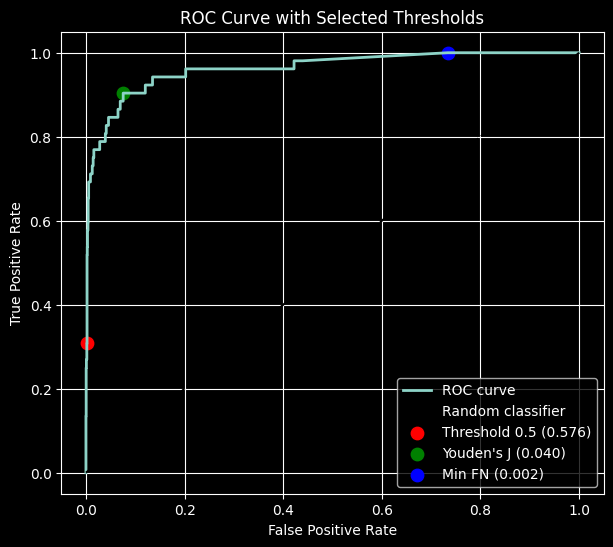

In [80]:
def roc_point_for_threshold(thr, fpr, tpr, thresholds):
    idx = np.argmin(np.abs(thresholds - thr))
    return fpr[idx], tpr[idx], thresholds[idx]

fpr_05, tpr_05, thr_05_used = roc_point_for_threshold(default_threshold, fpr, tpr, thresholds)
fpr_j, tpr_j, thr_j_used = fpr[j_idx], tpr[j_idx], thresholds[j_idx]
fpr_fn, tpr_fn, thr_fn_used = fpr[idx_fn], tpr[idx_fn], thresholds[idx_fn]

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label="ROC curve", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")

# Mark points
plt.scatter(fpr_05, tpr_05, color="red", s=80, label=f"Threshold 0.5 ({thr_05_used:.3f})")
plt.scatter(fpr_j, tpr_j, color="green", s=80, label=f"Youden's J ({thr_j_used:.3f})")
plt.scatter(fpr_fn, tpr_fn, color="blue", s=80, label=f"Min FN ({thr_fn_used:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Selected Thresholds")
plt.legend()
plt.grid(True)
plt.show()


Using the plot we can compare the suggested thresholds visually. Also, we could probably conclude that for this dataset, it might be actually a good idea to choose a point somewhere in between Youden's J and FN-minimizing (maybe FPR=0.2? Looks nice)

In [94]:
target_fpr = 0.2

idx = np.argmin(np.abs(fpr - target_fpr))
chosen_threshold = thresholds[idx]

print("Target FPR:", target_fpr)
print("Closest FPR:", fpr[idx])
print("TPR at that point:", tpr[idx])
print("Threshold:", chosen_threshold)
metrics(X_test, y_test, chosen_threshold)

Target FPR: 0.2
Closest FPR: 0.2022883295194508
TPR at that point: 0.9423076923076923
Threshold: 0.016055596075744815
Threshold: 0.0161
Accuracy:    0.8024
Precision:   0.0971
Recall:      0.9038
F1-score:    0.1754
Specificity: 0.8000
Sensitivity: 0.9038


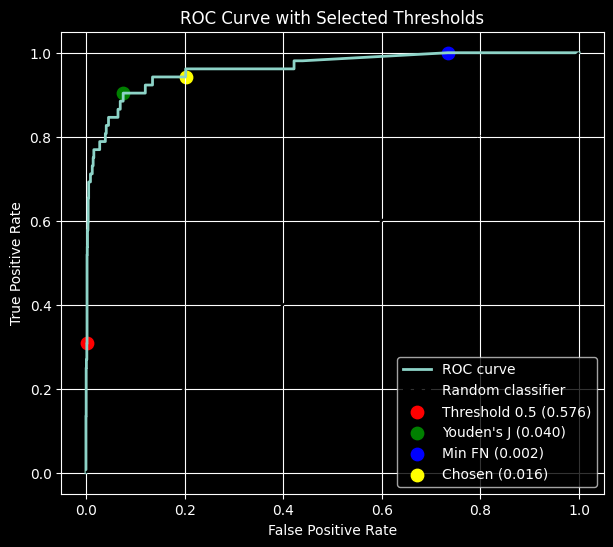

In [95]:
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label="ROC curve", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")

# Mark points
plt.scatter(fpr_05, tpr_05, color="red", s=80, label=f"Threshold 0.5 ({thr_05_used:.3f})")
plt.scatter(fpr_j, tpr_j, color="green", s=80, label=f"Youden's J ({thr_j_used:.3f})")
plt.scatter(fpr_fn, tpr_fn, color="blue", s=80, label=f"Min FN ({thr_fn_used:.3f})")
plt.scatter(fpr[idx], tpr[idx], color="yellow", s=80, label=f"Chosen ({chosen_threshold:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Selected Thresholds")
plt.legend()
plt.grid(True)
plt.show()